In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense 

In [2]:
df=pd.read_csv("Admission_Predict_Ver1.1.csv")

In [3]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
import matplotlib.pyplot as plt

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [6]:
df=df.drop("Serial No.",axis=1)

In [7]:
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,0.87
496,337,117,5,5.0,5.0,9.87,1,0.96
497,330,120,5,4.5,5.0,9.56,1,0.93
498,312,103,4,4.0,5.0,8.43,0,0.73


In [9]:
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,:-1],df["Chance of Admit "],test_size=0.2,random_state=42)

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
sc=MinMaxScaler()
X_train_scl=sc.fit_transform(X_train)
X_test_scl=sc.transform(X_test)

In [18]:
from tensorflow.keras import Sequential 

In [30]:
model=Sequential()

model.add(Dense(7,activation="relu",input_dim=7))
model.add(Dense(7,activation="relu"))
model.add(Dense(1,activation="linear"))

c:\Users\sm\AppData\Local\anaconda3\envs\dnn\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss="mean_squared_error",optimizer="Adam",metrics=["r2_score"])

In [33]:
history=model.fit(X_train_scl,y_train,epochs=50,validation_split=0.2)

Epoch 1/50


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 1.4110 - r2_score: -72.7389 - val_loss: 1.4290 - val_r2_score: -64.3791
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2220 - r2_score: -62.8601 - val_loss: 1.2397 - val_r2_score: -55.7160
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0632 - r2_score: -54.5632 - val_loss: 1.0841 - val_r2_score: -48.5969
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9396 - r2_score: -48.1026 - val_loss: 0.9667 - val_r2_score: -43.2279
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8426 - r2_score: -43.0328 - val_loss: 0.8748 - val_r2_score: -39.0209
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7615 - r2_score: -38.7975 - val_loss: 0.7941 - val_r2_score: -35.3319
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6890 - r2_score: -35.0071 - val_loss: 0.7223 - val_r2_score: -32.0441
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6225 - r2_score: -31.5327 - val_l

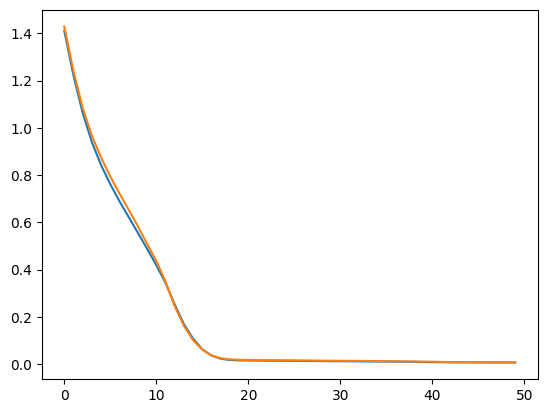

In [34]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

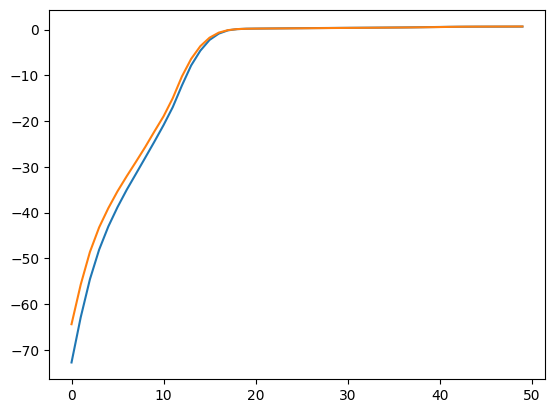

In [35]:
plt.plot(history.history["r2_score"])
plt.plot(history.history["val_r2_score"])

In [38]:
y_pred=model.predict(X_test_scl)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [39]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.5665553571911062